#  Stock Return Prediction using CatBoost

This notebook develops a baseline machine learning solution for predicting 1-year forward returns of US-listed stocks using fundamental financial data derived from SEC filings.

The workflow includes data exploration, preprocessing, feature analysis, grouped cross-validation, and extensive experimentation with multiple CatBoost configurations. Different combinations of model hyperparameters were evaluated, and the final model was selected based on cross-validation RMSE.

The notebook concludes by generating predictions for the competition test set and preparing a submission file.


#  Import Libraries

Import the required libraries for data manipulation, visualization, model training, and evaluation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
train = pd.read_csv("/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/train.csv")
test = pd.read_csv("/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/predict-1-year-us-stock-returns-from-fundamentals/sample_submission.csv")

## Dataset Summary

The dataset consists of 23,070 training observations and 8,520 test observations.

- **Training data:** Includes the target variable (`return_pct`) used for model development.
- **Test data:** Contains the same input features (excluding the target) and is used for generating competition submissions.
- **Sample submission:** Provides the required submission format with `id` and `return_pct` columns.

# Exploratory Data Analysis

This section explores the stock return prediction dataset provided for the competition. The objective is to understand the dataset, investigate feature distributions, analyze missing values, identify relationships among variables, and uncover insights that may improve predictive modeling.

The analysis focuses on:

- Dataset overview
- Missing value analysis
- Target variable exploration
- Numerical feature distributions
- Categorical feature analysis
- Correlation analysis
- Date feature exploration
- Key observations

In [3]:
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Sample Submission Shape: {sample_submission.shape}")

Train Shape: (23070, 39)
Test Shape: (8520, 36)
Sample Submission Shape: (8520, 2)


In [4]:
train.head()

,id,ticker,start_year,period_start,period_end,return_pct,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,gross_margin,operating_margin,net_margin,roa,roe,rote,revenue_growth_3y,revenue_growth_yoy,revenue_ttm,net_income_ttm,income_before_tax,eps_basic,eps_diluted,total_assets,stockholders_equity,current_assets,current_liabilities,long_term_debt,goodwill,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
0,0,AAPL,2022,2022-03-26,2023-04-01,-5.62,25.28,38.23,6.68,1.95,43.75,30.82,26.41,29.07,151.24,151.24,49.34,18.63,3.860170e+11,1.019350e+11,3.013900e+10,1.54,1.52,3.506620e+11,6.739900e+10,1.181800e+11,1.275080e+11,2.066460e+11,0.0,5.460000e+09,0.93,0.88,3.07,0.57,1.473400e+10,1.468700e+10,1.620757e+10,1.640332e+10,0.0
1,1,AAPL,2022,2022-06-25,2023-07-01,36.93,20.97,35.95,5.39,2.37,43.26,27.82,25.71,29.63,171.46,171.46,49.61,11.63,3.875420e+11,9.963300e+10,2.306600e+10,1.20,1.20,3.363090e+11,5.810700e+10,1.122920e+11,1.298730e+11,1.894000e+11,0.0,5.433000e+09,0.86,0.82,3.26,0.71,1.477800e+10,1.473400e+10,1.609538e+10,1.626220e+10,0.0
2,2,AAPL,2022,2022-09-24,2023-09-30,13.81,22.23,43.78,5.63,2.32,43.31,30.29,25.31,28.29,196.96,196.96,51.56,7.79,3.943280e+11,9.980300e+10,1.191030e+11,6.15,6.11,3.527550e+11,5.067200e+10,1.354050e+11,1.539820e+11,1.979180e+11,0.0,4.946000e+09,0.88,0.85,3.91,0.67,1.484100e+10,1.479300e+10,1.594342e+10,1.632582e+10,0.0
3,3,AAPL,2022,2022-12-31,2023-12-30,48.18,20.13,33.78,4.94,2.22,42.96,30.74,24.56,27.45,167.77,167.77,44.77,2.44,3.875370e+11,9.517100e+10,3.562300e+10,1.89,1.88,3.467470e+11,5.672700e+10,1.287770e+11,1.372860e+11,1.992540e+11,0.0,6.820000e+09,0.94,0.89,3.51,0.78,1.487700e+10,1.484000e+10,1.584241e+10,1.595572e+10,0.0
4,4,AAPL,2021,2021-03-27,2022-03-26,44.15,23.43,25.84,5.49,1.35,42.51,30.70,23.45,22.63,110.31,110.31,31.52,21.43,3.254060e+11,7.631100e+10,2.801100e+10,1.41,1.40,3.371580e+11,6.917800e+10,1.214650e+11,1.063850e+11,2.172840e+11,0.0,5.219000e+09,1.14,1.09,3.14,0.80,1.422700e+10,1.421200e+10,1.668630e+10,1.692916e+10,0.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23070 entries, 0 to 23069
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   23070 non-null  int64  
 1   ticker               23070 non-null  object 
 2   start_year           23070 non-null  int64  
 3   period_start         23070 non-null  object 
 4   period_end           23070 non-null  object 
 5   return_pct           23070 non-null  float64
 6   pe_ttm               20694 non-null  float64
 7   price_to_book        17537 non-null  float64
 8   price_to_sales       19357 non-null  float64
 9   growth_pe_ratio      15054 non-null  float64
 10  gross_margin         8660 non-null   float64
 11  operating_margin     19351 non-null  float64
 12  net_margin           20379 non-null  float64
 13  roa                  18387 non-null  float64
 14  roe                  18116 non-null  float64
 15  rote                 18611 non-null 

In [6]:
test.head()

,id,ticker,start_year,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,gross_margin,operating_margin,net_margin,roa,roe,rote,revenue_growth_3y,revenue_growth_yoy,revenue_ttm,net_income_ttm,income_before_tax,eps_basic,eps_diluted,total_assets,stockholders_equity,current_assets,current_liabilities,long_term_debt,goodwill,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
0,0,stock_0820,2024,NaN,NaN,NaN,NaN,38.62,-122.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5435000.0,-0.21,-0.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.546700e+07,0.0
1,1,stock_0238,2024,14.76,NaN,2.09,NaN,NaN,23.45,14.15,NaN,NaN,NaN,NaN,NaN,1.386100e+08,1.961600e+07,27451000.0,4.81,4.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.087000e+06,4.0
2,2,stock_0704,2024,25.46,0.98,1.74,0.76,NaN,NaN,6.85,0.47,3.85,4.09,19.47,-19.78,7.554160e+08,5.176500e+07,18008000.0,0.13,0.13,1.103751e+10,1.342895e+09,NaN,NaN,0.000000e+00,7.571700e+07,NaN,NaN,NaN,0.00,0.0,0.0,NaN,1.124020e+08,1.139223e+08,1.0
3,3,stock_0689,2024,14.43,1.34,1.54,-2.40,NaN,17.03,10.65,2.30,9.26,12.41,-34.58,14.36,2.275000e+10,2.422000e+09,494000000.0,0.45,0.45,1.051130e+11,2.615200e+10,8.557000e+09,8.275000e+09,8.607800e+10,6.630000e+09,294000000.0,1.03,1.00,3.29,NaN,NaN,NaN,1.000000e+09,1.001000e+09,9.0
4,4,stock_0006,2024,-316.67,45.39,12.36,NaN,82.05,1.50,-3.90,-3.21,-14.33,107.24,NaN,NaN,4.166111e+09,-1.625520e+08,19775000.0,0.05,0.05,5.063265e+09,1.134171e+09,2.913929e+09,2.468213e+09,1.849448e+09,1.285745e+09,NaN,1.18,1.18,1.63,NaN,NaN,NaN,NaN,2.617780e+08,0.0


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8520 entries, 0 to 8519
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8520 non-null   int64  
 1   ticker               8520 non-null   object 
 2   start_year           8520 non-null   int64  
 3   pe_ttm               6995 non-null   float64
 4   price_to_book        5957 non-null   float64
 5   price_to_sales       6530 non-null   float64
 6   growth_pe_ratio      4947 non-null   float64
 7   gross_margin         3318 non-null   float64
 8   operating_margin     7221 non-null   float64
 9   net_margin           6947 non-null   float64
 10  roa                  6054 non-null   float64
 11  roe                  6145 non-null   float64
 12  rote                 6212 non-null   float64
 13  revenue_growth_3y    5309 non-null   float64
 14  revenue_growth_yoy   6272 non-null   float64
 15  revenue_ttm          6972 non-null   f

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,23070.0,1.153450e+04,6.659880e+03,0.000000e+00,5.767250e+03,1.153450e+04,1.730175e+04,2.306900e+04
start_year,23070.0,2.020620e+03,1.116563e+00,2.019000e+03,2.020000e+03,2.021000e+03,2.022000e+03,2.022000e+03
return_pct,23070.0,1.877874e+01,1.386501e+02,-9.917000e+01,-1.978750e+01,3.500000e+00,3.382750e+01,1.057111e+04
pe_ttm,20694.0,4.419552e+06,1.848069e+08,-2.378991e+08,-3.400000e-01,1.521000e+01,3.042750e+01,1.251553e+10
price_to_book,17537.0,1.318639e+03,5.618679e+04,-1.393592e+05,1.440000e+00,2.960000e+00,6.610000e+00,5.271275e+06
price_to_sales,19357.0,3.847464e+01,6.236856e+02,0.000000e+00,1.060000e+00,2.650000e+00,6.350000e+00,5.311876e+04
growth_pe_ratio,15054.0,8.125820e-01,1.454607e+01,-1.000000e+02,0.000000e+00,6.900000e-01,2.050000e+00,1.000000e+02
gross_margin,8660.0,6.495153e+01,2.091963e+03,-8.276250e+04,2.511750e+01,3.860500e+01,5.652500e+01,1.376397e+05
operating_margin,19351.0,-4.193572e+02,1.270640e+04,-1.237600e+06,1.390000e+00,1.022000e+01,2.050500e+01,9.353684e+04
net_margin,20379.0,-1.349116e+02,4.522532e+03,-2.182141e+05,1.700000e-01,7.270000e+00,1.604000e+01,1.042477e+05


## Missing Value Analysis

Missing values are common in financial datasets due to differences in reporting requirements, company characteristics, and unavailable financial metrics.

This section examines the proportion of missing values in each feature to identify highly sparse variables and understand potential preprocessing requirements.

In [9]:
missing = pd.DataFrame({
    "Missing": train.isnull().sum(),
    "Percent": train.isnull().mean() * 100
})

missing = (
    missing[missing["Missing"] > 0]
    .sort_values("Percent", ascending=False)
)

missing

,Missing,Percent
dividends_paid_ttm,21505,93.216298
dividend_yield,16617,72.028609
dividends_ttm,16336,70.810577
gross_margin,14410,62.462072
inventory,11514,49.908973
debt_to_equity,8592,37.243173
shares_outstanding,8161,35.374946
growth_pe_ratio,8016,34.746424
income_before_tax,7985,34.612050
long_term_debt,7636,33.099263


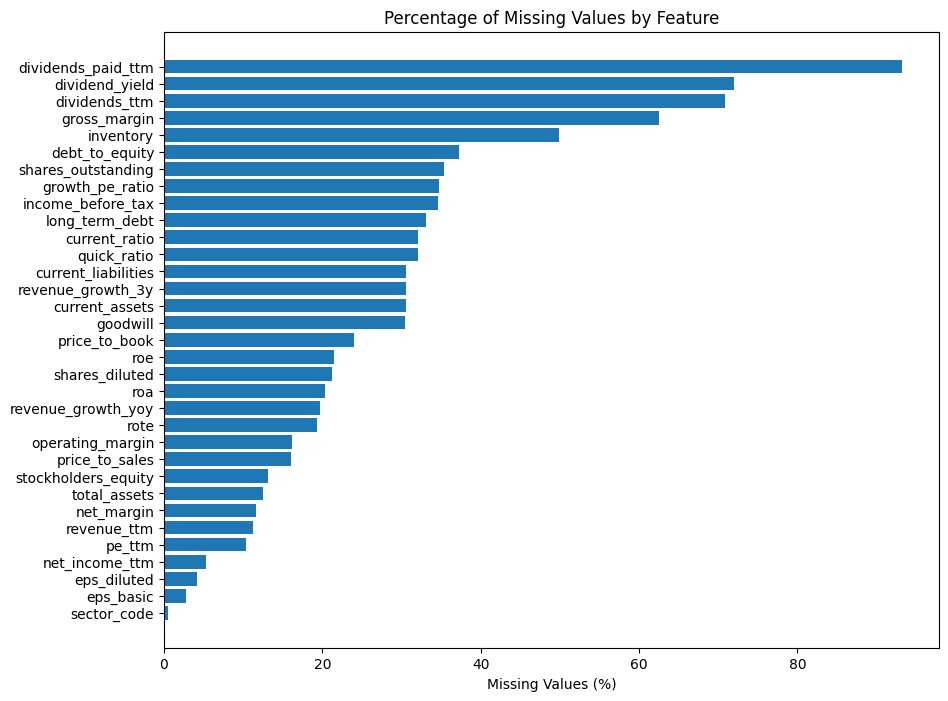

In [10]:
plt.figure(figsize=(10,8))

plt.barh(
    missing.index,
    missing["Percent"]
)

plt.xlabel("Missing Values (%)")
plt.title("Percentage of Missing Values by Feature")

plt.gca().invert_yaxis()

plt.show()

In [11]:
missing_compare = pd.DataFrame({
    "Train (%)": train.isnull().mean() * 100,
    "Test (%)": test.isnull().mean() * 100
})

missing_compare = (
    missing_compare
    .sort_values("Train (%)", ascending=False)
)

missing_compare.head(20)

,Train (%),Test (%)
dividends_paid_ttm,93.216298,94.495305
dividend_yield,72.028609,76.995305
dividends_ttm,70.810577,75.845070
gross_margin,62.462072,61.056338
inventory,49.908973,55.704225
debt_to_equity,37.243173,43.732394
shares_outstanding,35.374946,41.408451
growth_pe_ratio,34.746424,41.936620
income_before_tax,34.612050,21.455399
long_term_debt,33.099263,41.819249


### Key Findings

- Several financial variables contain substantial missing values.
- `dividends_paid_ttm` is missing in over 90% of the observations and is a strong candidate for removal.
- Dividend-related features are generally sparse, while most remaining financial variables have moderate levels of missingness.
- The missing value patterns in the training and test datasets are largely consistent, suggesting no major distribution shift in terms of data availability.
- Since CatBoost can naturally handle missing values, extensive imputation may not be necessary for the initial baseline model.

## Target Variable Analysis

The target variable, `return_pct`, represents the one-year forward stock return.

Understanding its distribution is essential because financial returns are often non-normal, highly skewed, and contain extreme outliers. These characteristics can significantly influence model performance and evaluation.

In [12]:
train["return_pct"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame()

,return_pct
count,23070.000000
mean,18.778736
std,138.650112
min,-99.170000
1%,-80.195500
5%,-56.198500
25%,-19.787500
50%,3.500000
75%,33.827500
95%,118.077000


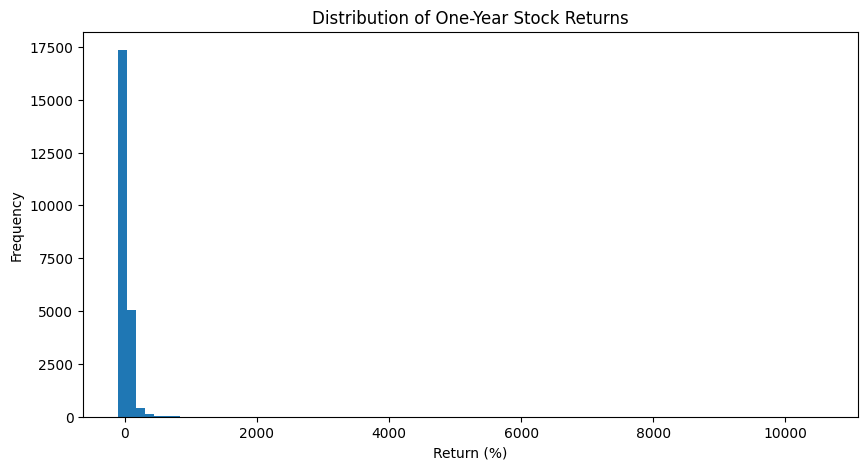

In [13]:
plt.figure(figsize=(10,5))

plt.hist(train["return_pct"], bins=80)

plt.title("Distribution of One-Year Stock Returns")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")

plt.show()

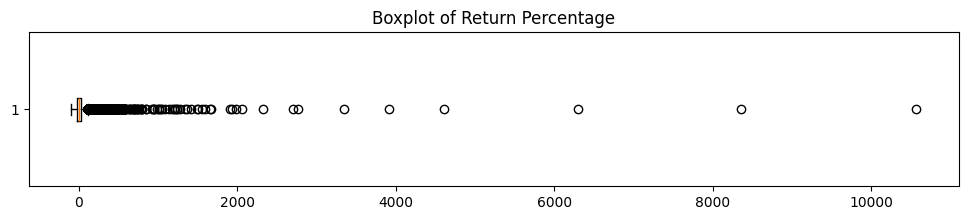

In [14]:
plt.figure(figsize=(12,2))

plt.boxplot(train["return_pct"], vert=False)

plt.title("Boxplot of Return Percentage")

plt.show()

In [15]:
print(f"Mean      : {train['return_pct'].mean():.2f}")
print(f"Median    : {train['return_pct'].median():.2f}")
print(f"Std Dev   : {train['return_pct'].std():.2f}")
print(f"Skewness  : {train['return_pct'].skew():.2f}")
print(f"Kurtosis  : {train['return_pct'].kurt():.2f}")

Mean      : 18.78
Median    : 3.50
Std Dev   : 138.65
Skewness  : 38.28
Kurtosis  : 2329.23


In [16]:
print("Top 10 Highest Returns")
display(train.nlargest(10, "return_pct")[["ticker", "return_pct"]])

print("Top 10 Lowest Returns")
display(train.nsmallest(10, "return_pct")[["ticker", "return_pct"]])

Top 10 Highest Returns


,ticker,return_pct
8266,MARA,10571.11
5109,GME,8363.54
7988,RIOT,6294.96
22336,AMTX,4615.38
5111,GME,3917.95
8267,MARA,3347.25
5110,GME,2769.26
5202,NVAX,2701.76
21937,ACRS,2323.08
5201,NVAX,2058.37


Top 10 Lowest Returns


,ticker,return_pct
865,AVX,-99.17
4580,CVNA,-97.96
21812,ACBM,-97.67
9072,PR,-97.01
8895,CLSK,-96.55
8548,PRAX,-95.89
10145,WULF,-95.56
10146,WULF,-95.55
22292,AMPY,-94.17
9791,WGS,-94.08


### Key Findings

- The target distribution is expected to be non-normal with noticeable outliers.
- Most observations are concentrated around modest returns, while a relatively small number of stocks exhibit extremely large gains or losses.
- Such heavy-tailed behavior is common in financial markets and suggests that robust validation and careful feature engineering will be more impactful than aggressive preprocessing.
- For the initial baseline, the target will be kept unchanged without clipping or transformation.

# Categorical Feature Analysis

This section explores the categorical variables in the dataset. Understanding the distribution of companies across sectors and the frequency of ticker observations helps assess data balance and guides validation strategy.

## 1. Number of Unique Companies

In [17]:
print(f"Unique tickers in train: {train['ticker'].nunique()}")
print(f"Unique tickers in test : {test['ticker'].nunique()}")

Unique tickers in train: 1734
Unique tickers in test : 2200


## 2. Most Frequent Companies

In [18]:
train["ticker"].value_counts().head(15)

ticker
ET      32
PLD     32
AGCO    16
LASR    16
CSR     16
MDXG    16
LPG     16
NSSC    16
LZB     16
LNN     16
EVR     16
HMN     16
CNXN    16
PPC     16
WWD     16
Name: count, dtype: int64

## 3. Sector Distribution

In [19]:
train["sector_code"].value_counts().sort_index()

sector_code
0.0     3695
1.0     3840
2.0     3542
3.0     3180
4.0     2837
5.0     1601
6.0     1166
7.0     1086
8.0      919
9.0      719
10.0     381
Name: count, dtype: int64

## 4. Sector Bar Chart

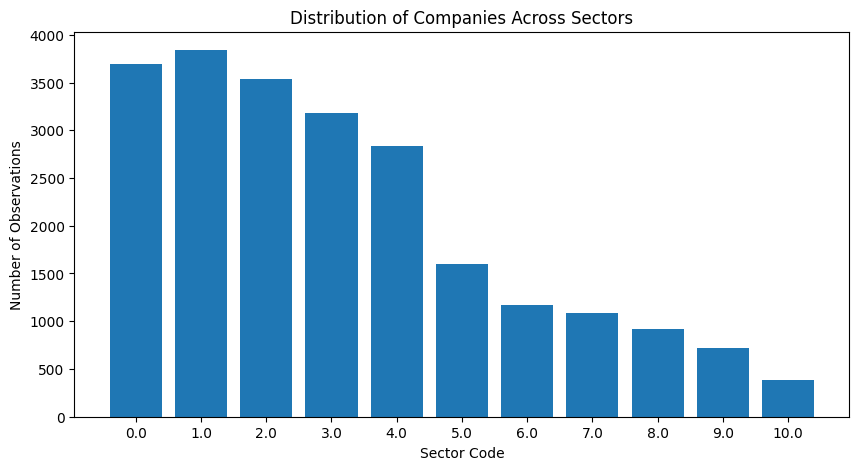

In [20]:
sector_counts = train["sector_code"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.bar(
    sector_counts.index.astype(str),
    sector_counts.values
)

plt.title("Distribution of Companies Across Sectors")
plt.xlabel("Sector Code")
plt.ylabel("Number of Observations")

plt.show()

## 5. Average Return by Sector

In [21]:
sector_return = (
    train
    .groupby("sector_code")["return_pct"]
    .mean()
    .sort_values()
)

sector_return

sector_code
5.0      2.189844
10.0     5.020052
9.0      5.261530
1.0     12.459453
7.0     12.902578
0.0     21.081575
2.0     21.181683
3.0     21.915525
4.0     26.139912
6.0     27.699134
8.0     35.091099
Name: return_pct, dtype: float64

## 6. Plot Average Return by Sector

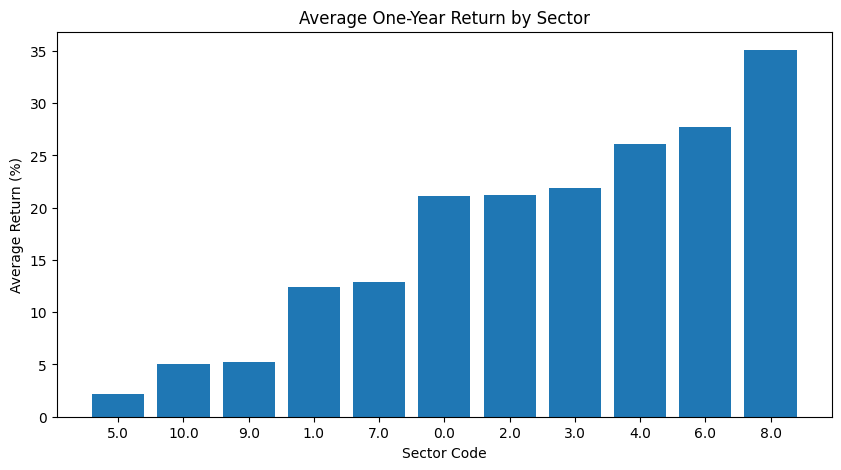

In [22]:
plt.figure(figsize=(10,5))

plt.bar(
    sector_return.index.astype(str),
    sector_return.values
)

plt.title("Average One-Year Return by Sector")
plt.xlabel("Sector Code")
plt.ylabel("Average Return (%)")

plt.show()

# Numerical Feature Analysis

The dataset contains a variety of financial ratios, profitability metrics, balance sheet variables, and growth indicators.

This section examines the distribution of numerical features, identifies skewed variables, and explores relationships with the target variable.

In [23]:
target = "return_pct"

exclude_cols = [
    "id",
    "ticker",
    "sector_code",
    "period_start",
    "period_end",
    target
]

numeric_features = [
    col for col in train.columns
    if col not in exclude_cols
]

print(f"Number of numerical features: {len(numeric_features)}")
numeric_features

Number of numerical features: 33


['start_year',
 'pe_ttm',
 'price_to_book',
 'price_to_sales',
 'growth_pe_ratio',
 'gross_margin',
 'operating_margin',
 'net_margin',
 'roa',
 'roe',
 'rote',
 'revenue_growth_3y',
 'revenue_growth_yoy',
 'revenue_ttm',
 'net_income_ttm',
 'income_before_tax',
 'eps_basic',
 'eps_diluted',
 'total_assets',
 'stockholders_equity',
 'current_assets',
 'current_liabilities',
 'long_term_debt',
 'goodwill',
 'inventory',
 'current_ratio',
 'quick_ratio',
 'debt_to_equity',
 'dividend_yield',
 'dividends_ttm',
 'dividends_paid_ttm',
 'shares_outstanding',
 'shares_diluted']

In [24]:
train[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
start_year,23070.0,2.020620e+03,1.116563e+00,2.019000e+03,2.020000e+03,2.021000e+03,2.022000e+03,2.022000e+03
pe_ttm,20694.0,4.419552e+06,1.848069e+08,-2.378991e+08,-3.400000e-01,1.521000e+01,3.042750e+01,1.251553e+10
price_to_book,17537.0,1.318639e+03,5.618679e+04,-1.393592e+05,1.440000e+00,2.960000e+00,6.610000e+00,5.271275e+06
price_to_sales,19357.0,3.847464e+01,6.236856e+02,0.000000e+00,1.060000e+00,2.650000e+00,6.350000e+00,5.311876e+04
growth_pe_ratio,15054.0,8.125820e-01,1.454607e+01,-1.000000e+02,0.000000e+00,6.900000e-01,2.050000e+00,1.000000e+02
gross_margin,8660.0,6.495153e+01,2.091963e+03,-8.276250e+04,2.511750e+01,3.860500e+01,5.652500e+01,1.376397e+05
operating_margin,19351.0,-4.193572e+02,1.270640e+04,-1.237600e+06,1.390000e+00,1.022000e+01,2.050500e+01,9.353684e+04
net_margin,20379.0,-1.349116e+02,4.522532e+03,-2.182141e+05,1.700000e-01,7.270000e+00,1.604000e+01,1.042477e+05
roa,18387.0,2.387002e+00,1.146044e+02,-2.617510e+03,9.000000e-02,3.450000e+00,7.880000e+00,1.470560e+04
roe,18116.0,1.205656e+03,4.354509e+04,-1.206824e+06,-1.000000e-01,1.025000e+01,2.120000e+01,3.361580e+06


## Skewness Analysis

Evaluate skewness across numerical variables to understand the characteristics of financial data.

In [25]:
skewness = (
    train[numeric_features]
    .skew()
    .sort_values(key=abs, ascending=False)
    .to_frame("Skewness")
)

skewness

,Skewness
revenue_growth_yoy,125.493291
eps_basic,120.473787
roa,114.492363
eps_diluted,93.353513
revenue_growth_3y,85.890372
price_to_book,69.278682
rote,67.772372
operating_margin,-64.786626
shares_diluted,53.597172
pe_ttm,52.664839


In [26]:
train[numeric_features].isnull().mean().sort_values(ascending=False) * 100

dividends_paid_ttm     93.216298
dividend_yield         72.028609
dividends_ttm          70.810577
gross_margin           62.462072
inventory              49.908973
debt_to_equity         37.243173
shares_outstanding     35.374946
growth_pe_ratio        34.746424
income_before_tax      34.612050
long_term_debt         33.099263
quick_ratio            32.050282
current_ratio          32.050282
current_liabilities    30.611183
revenue_growth_3y      30.559168
current_assets         30.550498
goodwill               30.472475
price_to_book          23.983528
roe                    21.473775
shares_diluted         21.183355
roa                    20.299090
revenue_growth_yoy     19.692241
rote                   19.328132
operating_margin       16.120503
price_to_sales         16.094495
stockholders_equity    13.138275
total_assets           12.466407
net_margin             11.664499
revenue_ttm            11.226701
pe_ttm                 10.299090
net_income_ttm          5.327265
eps_dilute

## Correlation with target

Measure the linear relationship between each numerical feature and the target variable (`return_pct`).

In [27]:
corr_target = (
    train[numeric_features + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values()
)

corr_target

start_year            -0.052942
growth_pe_ratio       -0.050707
goodwill              -0.028519
long_term_debt        -0.025231
net_income_ttm        -0.024221
income_before_tax     -0.020608
dividends_ttm         -0.020246
stockholders_equity   -0.019968
roa                   -0.019680
current_liabilities   -0.019617
total_assets          -0.017632
current_assets        -0.017308
inventory             -0.016612
revenue_ttm           -0.014480
current_ratio         -0.011263
quick_ratio           -0.010885
price_to_book         -0.009461
roe                   -0.008736
debt_to_equity        -0.006175
rote                  -0.006069
shares_diluted        -0.005703
pe_ttm                -0.004960
price_to_sales        -0.004482
revenue_growth_yoy    -0.003082
net_margin            -0.002404
gross_margin          -0.001734
eps_diluted           -0.001445
eps_basic             -0.000726
operating_margin       0.007597
revenue_growth_3y      0.011623
shares_outstanding     0.020190
dividend

 The largest absolute correlation is only about 0.095 (dividend_yield).
That means there is no single feature that strongly predicts future returns. The predictive signal is likely to come from combinations of features, not individual variables.

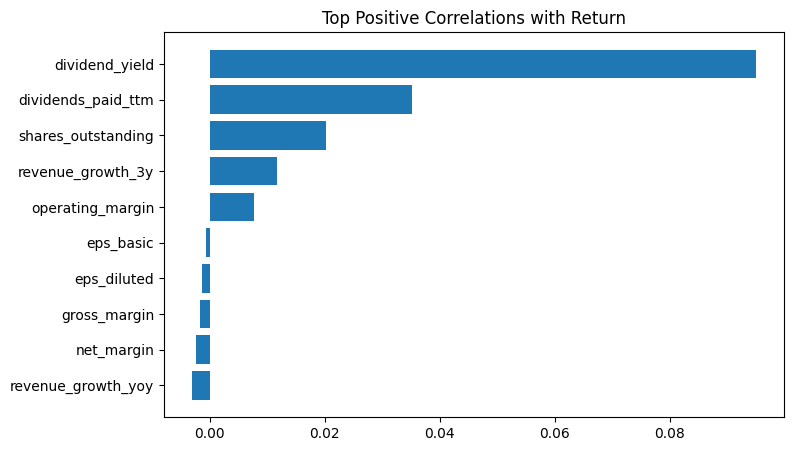

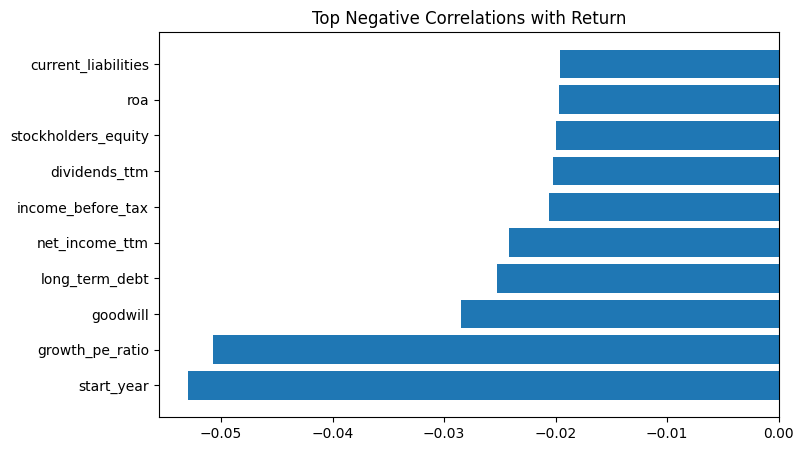

In [28]:
top_pos = corr_target.tail(10)
top_neg = corr_target.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_pos.index, top_pos.values)
plt.title("Top Positive Correlations with Return")
plt.show()

plt.figure(figsize=(8,5))
plt.barh(top_neg.index, top_neg.values)
plt.title("Top Negative Correlations with Return")
plt.show()

##  Correlation heatmap

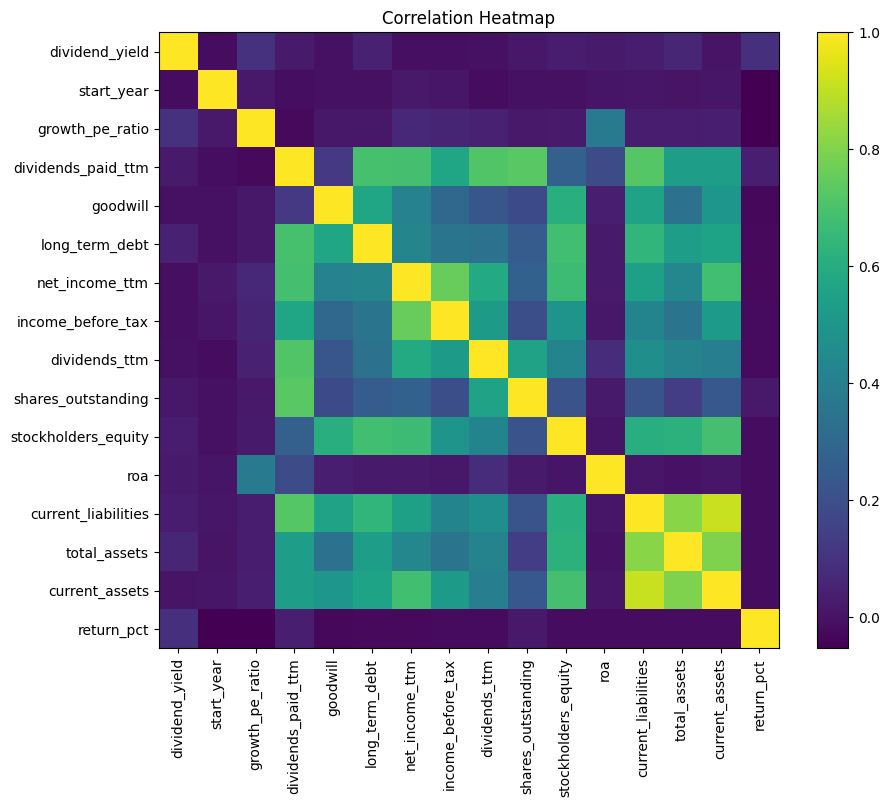

In [29]:
top_features = corr_target.abs().sort_values(ascending=False).head(15).index

corr_matrix = train[list(top_features) + [target]].corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, aspect="auto")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.colorbar()
plt.title("Correlation Heatmap")

plt.show()

In [31]:
corr = train[numeric_features].corr(numeric_only=True)

# Finding highly correlated feature pairs
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.80:
            high_corr.append((
                corr.columns[i],
                corr.columns[j],
                corr.iloc[i, j]
            ))

high_corr = pd.DataFrame(
    high_corr,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr.sort_values("Correlation", ascending=False)

,Feature 1,Feature 2,Correlation
2,current_ratio,quick_ratio,0.996482
1,current_assets,current_liabilities,0.910836
0,total_assets,current_liabilities,0.814571


## Exploratory Data Analysis Key Findings

- The dataset contains over 23,000 training observations and 8,500 test observations.
- Several financial variables contain moderate to high levels of missing values. Only `dividends_paid_ttm` is missing in over 90% of observations and is a candidate for removal.
- Most numerical features exhibit substantial skewness, reflecting the heterogeneous nature of company fundamentals.
- Individual features have only weak linear correlations with the target variable, suggesting that future stock returns depend on complex, nonlinear interactions among multiple financial metrics.
- Strong correlations exist among a few financial variables (e.g., `current_ratio` and `quick_ratio`), which is expected for related accounting measures. Tree-based models such as CatBoost can naturally handle this redundancy.
- These findings support the use of gradient boosting models combined with feature engineering and robust cross-validation.

# Data Preprocessing

Before training the model, the data is prepared by:

- Removing highly sparse features.
- Converting date columns to datetime format.
- Extracting useful calendar-based features.
- Identifying categorical variables for CatBoost.

## Preparing Features

Separate predictor variables from the target and create the final training and testing datasets.

In [44]:
train_model = train.copy()
test_model = test.copy()

# Drop highly sparse feature
drop_cols = ["dividends_paid_ttm"]

train_model.drop(columns=drop_cols, inplace=True)
test_model.drop(columns=drop_cols, inplace=True)

# Drop date columns from train since they are unavailable in test
train_model.drop(columns=["period_start", "period_end"], inplace=True)

TARGET = "return_pct"

X = train_model.drop(columns=[TARGET])
y = train_model[TARGET]

X_test = test_model.copy()

cat_features = ["ticker", "sector_code"]

print(X.shape)
print(X_test.shape)
print(X.columns.symmetric_difference(X_test.columns))

(23070, 35)
(8520, 35)
Index([], dtype='object')


In [49]:
for col in cat_features:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# CatBoost Model Development

Training multiple CatBoost Regressors using grouped cross-validation to reduce information leakage between observations from the same company.

In [50]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import root_mean_squared_error
from catboost import CatBoostRegressor

## Cross-Validation

Use GroupKFold with stock tickers as groups to ensure that observations from the same company are not split across training and validation folds.

In [51]:
groups = train_model["ticker"]

gkf = GroupKFold(n_splits=5)

In [52]:
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=200,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_features,
        use_best_model=True
    )

    preds = model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))

    print("RMSE:", rmse)

    cv_scores.append(rmse)

    oof[valid_idx] = preds

    test_preds += model.predict(X_test) / gkf.n_splits


Fold 1
0:	learn: 149.1913328	test: 80.8475557	best: 80.8475557 (0)	total: 73.1ms	remaining: 3m 39s
200:	learn: 108.3540859	test: 72.7458783	best: 72.7458783 (200)	total: 2.57s	remaining: 35.8s
400:	learn: 86.9698304	test: 71.5857204	best: 71.5336662 (398)	total: 5.06s	remaining: 32.8s
600:	learn: 75.2277961	test: 71.5708281	best: 71.5099912 (458)	total: 7.4s	remaining: 29.5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 71.50999122
bestIteration = 458

Shrink model to first 459 iterations.
RMSE: 71.50999159134085

Fold 2
0:	learn: 126.3571383	test: 177.0761400	best: 177.0761400 (0)	total: 11.8ms	remaining: 35.5s
200:	learn: 89.0193273	test: 171.8894392	best: 171.8894392 (200)	total: 2.36s	remaining: 32.9s
400:	learn: 76.3306585	test: 170.6923205	best: 170.6758824 (399)	total: 4.81s	remaining: 31.2s
600:	learn: 67.3453855	test: 170.3184405	best: 170.1804247 (557)	total: 7.35s	remaining: 29.4s
800:	learn: 61.2665164	test: 170.2303454	best: 170.1720474 (712)	total: 9

## Model Evaluation

Evaluate model performance using Root Mean Squared Error (RMSE) across all validation folds.

In [53]:
print("\nMean CV RMSE:", np.mean(cv_scores))
print("Std CV RMSE :", np.std(cv_scores))


Mean CV RMSE: 125.21522866192576
Std CV RMSE : 41.22779629075693


#  Feature Importance

Visualize CatBoost feature importance to understand which financial variables contribute most to prediction performance.

In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
2,start_year,28.400240
6,growth_pe_ratio,16.979499
5,price_to_sales,9.911470
15,revenue_ttm,5.887386
26,inventory,4.187212
0,id,3.939933
16,net_income_ttm,3.591714
23,current_liabilities,3.560621
18,eps_basic,3.508382
34,sector_code,3.017931


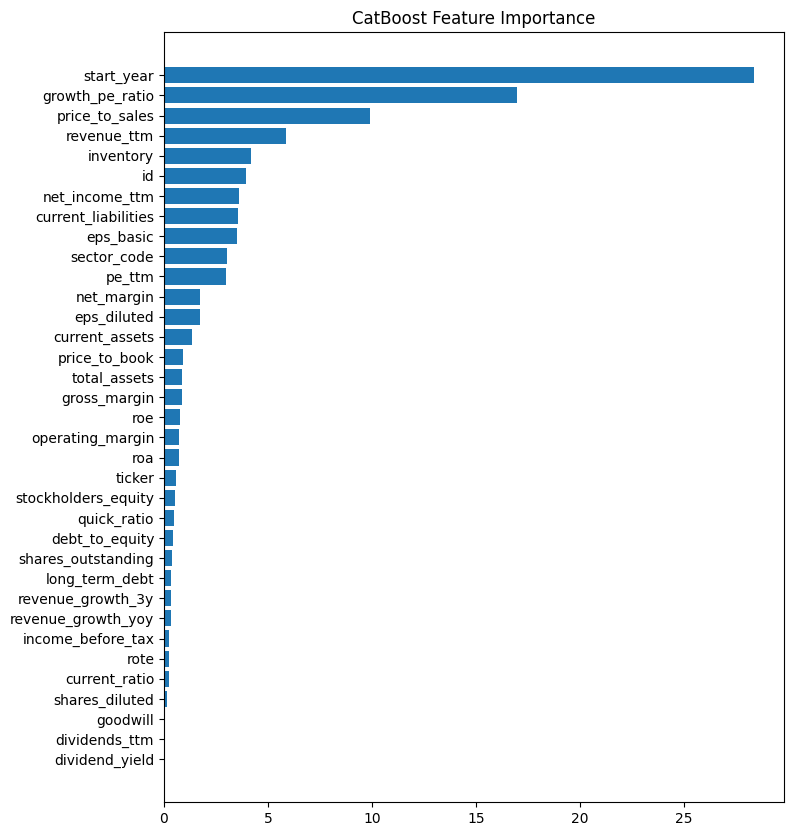

In [55]:
plt.figure(figsize=(8,10))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("CatBoost Feature Importance")
plt.show()

In [68]:
train_model["ticker"] = train_model["ticker"].fillna("Missing").astype(str)
test_model["ticker"] = test_model["ticker"].fillna("Missing").astype(str)

train_model["sector_code"] = train_model["sector_code"].fillna("Missing").astype(str)
test_model["sector_code"] = test_model["sector_code"].fillna("Missing").astype(str)

train_model.drop(columns=["id"], inplace=True)
test_model.drop(columns=["id"], inplace=True)

In [88]:


TARGET = "return_pct"

X = train_model.drop(columns=[TARGET])
y = train_model[TARGET]
X_test = test_model.copy()

In [70]:
for df in [train_model, test_model]:

    df["earnings_yield"] = 1 / (df["pe_ttm"] + 1)

    df["book_yield"] = 1 / (df["price_to_book"] + 1)

    df["sales_yield"] = 1 / (df["price_to_sales"] + 1)

    df["asset_turnover"] = (
        df["revenue_ttm"] /
        (df["total_assets"] + 1)
    )

    df["debt_ratio"] = (
        df["long_term_debt"] /
        (df["total_assets"] + 1)
    )

    df["equity_ratio"] = (
        df["stockholders_equity"] /
        (df["total_assets"] + 1)
    )

In [71]:
X[["ticker", "sector_code"]].dtypes

ticker         object
sector_code    object
dtype: object

In [72]:
cat_features = ["ticker", "sector_code"]

for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)

In [73]:
X[cat_features].dtypes

ticker         object
sector_code    object
dtype: object

In [74]:
print(X["sector_code"].unique()[:10])
print(X_test["sector_code"].unique()[:10])

['0.0' '3.0' '4.0' '1.0' '7.0' '8.0' '2.0' '10.0' '6.0' '9.0']
['0.0' '4.0' '1.0' '9.0' '2.0' '3.0' '8.0' '5.0' '6.0' '10.0']


In [75]:
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=300,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_features,
        use_best_model=True
    )

    preds = model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))

    print("RMSE:", rmse)

    cv_scores.append(rmse)

    oof[valid_idx] = preds

    test_preds += model.predict(X_test) / gkf.n_splits


Fold 1
0:	learn: 148.7949025	test: 80.8379324	best: 80.8379324 (0)	total: 30.3ms	remaining: 2m 31s
200:	learn: 104.1335991	test: 73.1647934	best: 73.1647934 (200)	total: 5.02s	remaining: 1m 59s
400:	learn: 78.4954555	test: 72.2751829	best: 72.2715547 (372)	total: 9.99s	remaining: 1m 54s
600:	learn: 64.4886759	test: 73.2072456	best: 72.2633446 (403)	total: 15.2s	remaining: 1m 51s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 72.26334456
bestIteration = 403

Shrink model to first 404 iterations.
RMSE: 72.26334490439562

Fold 2
0:	learn: 126.4841814	test: 177.0119353	best: 177.0119353 (0)	total: 29ms	remaining: 2m 24s
200:	learn: 83.3010812	test: 172.9982287	best: 172.9775520 (193)	total: 5.05s	remaining: 2m
400:	learn: 67.3378795	test: 172.3334407	best: 172.1649248 (357)	total: 10.2s	remaining: 1m 56s
600:	learn: 58.0363170	test: 172.4681900	best: 172.1649248 (357)	total: 15.4s	remaining: 1m 52s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 172.

In [76]:
print("\nMean CV RMSE:", np.mean(cv_scores))
print("Std CV RMSE :", np.std(cv_scores))


Mean CV RMSE: 125.91191380372243
Std CV RMSE : 41.875070689162506


In [77]:
for df in [train_model, test_model]:

    df["earnings_yield"] = 1 / (df["pe_ttm"] + 1)
    df["book_yield"] = 1 / (df["price_to_book"] + 1)
    df["sales_yield"] = 1 / (df["price_to_sales"] + 1)

    df["asset_turnover"] = df["revenue_ttm"] / (df["total_assets"] + 1)
    df["debt_ratio"] = df["long_term_debt"] / (df["total_assets"] + 1)
    df["equity_ratio"] = df["stockholders_equity"] / (df["total_assets"] + 1)

In [78]:
X = train_model.drop(columns=[TARGET])
y = train_model[TARGET]
X_test = test_model.copy()

for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)

In [80]:
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=300,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_features,
        use_best_model=True
    )

    preds = model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))

    print("RMSE:", rmse)

    cv_scores.append(rmse)

    oof[valid_idx] = preds

    test_preds += model.predict(X_test) / gkf.n_splits


Fold 1
0:	learn: 148.9533965	test: 80.8400769	best: 80.8400769 (0)	total: 25.9ms	remaining: 2m 9s
200:	learn: 115.4456656	test: 73.1357099	best: 73.1350984 (197)	total: 5.47s	remaining: 2m 10s
400:	learn: 97.9799065	test: 72.1259934	best: 72.1236135 (397)	total: 10.2s	remaining: 1m 57s
600:	learn: 84.2578175	test: 71.9222020	best: 71.8269370 (573)	total: 15.2s	remaining: 1m 51s
800:	learn: 71.3860131	test: 72.4242381	best: 71.8269370 (573)	total: 20.4s	remaining: 1m 47s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 71.82693705
bestIteration = 573

Shrink model to first 574 iterations.
RMSE: 71.82693737406329

Fold 2
0:	learn: 126.6836580	test: 177.0509788	best: 177.0509788 (0)	total: 26.6ms	remaining: 2m 12s
200:	learn: 92.5492373	test: 173.8077763	best: 173.8077763 (200)	total: 5.05s	remaining: 2m
400:	learn: 75.7112704	test: 172.8325604	best: 172.8064475 (390)	total: 9.8s	remaining: 1m 52s
600:	learn: 66.1684267	test: 172.8575119	best: 172.8022586 (413)	total: 1

In [82]:
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=10,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=300,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_features,
        use_best_model=True
    )

    preds = model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, preds))

    print("RMSE:", rmse)

    cv_scores.append(rmse)

    oof[valid_idx] = preds

    test_preds += model.predict(X_test) / gkf.n_splits


Fold 1
0:	learn: 149.3346679	test: 80.9130705	best: 80.9130705 (0)	total: 15.2ms	remaining: 1m 16s
200:	learn: 133.9417557	test: 74.7254759	best: 74.7254759 (200)	total: 2.54s	remaining: 1m
400:	learn: 125.7998925	test: 73.5842038	best: 73.5842038 (400)	total: 4.97s	remaining: 57s
600:	learn: 121.0103073	test: 73.2022074	best: 73.2011218 (578)	total: 7.33s	remaining: 53.6s
800:	learn: 115.7025889	test: 72.6847621	best: 72.6789136 (797)	total: 9.65s	remaining: 50.6s
1000:	learn: 111.8109175	test: 72.3828602	best: 72.3789436 (982)	total: 12.1s	remaining: 48.2s
1200:	learn: 105.8533283	test: 71.9621125	best: 71.9466772 (1166)	total: 14.5s	remaining: 46s
1400:	learn: 102.1688036	test: 71.9864497	best: 71.9078876 (1257)	total: 16.9s	remaining: 43.4s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 71.90788756
bestIteration = 1257

Shrink model to first 1258 iterations.
RMSE: 71.90788789573857

Fold 2
0:	learn: 126.9365496	test: 177.1068028	best: 177.1068028 (0)	total: 13.

In [83]:
oof_rmse = np.sqrt(mean_squared_error(y, oof))
print(oof_rmse)

133.65493473903243


**The final model configuration is selected based on its cross-validation RMSE, providing the best balance between predictive performance and generalization. Early stopping was used during training to reduce overfitting and automatically determine the optimal number of boosting iterations.**

# Generate Submission

Generate predictions for the test dataset and prepare the submission file in the required competition format.

In [84]:
submission = sample_submission.copy()
submission["return_pct"] = test_preds
submission.to_csv("submission.csv", index=False)
submission.head()

,id,return_pct
0,0,-1.882997
1,1,-0.092421
2,2,1.494455
3,3,-2.333439
4,4,1.054529


In [85]:
submission.isna().sum()

id            0
return_pct    0
dtype: int64

In [87]:
submission.shape


(8520, 2)

# Conclusion

A complete CatBoost-based prediction pipeline was developed for the stock return forecasting task. The project included exploratory data analysis, missing value assessment, feature importance analysis, preprocessing, grouped cross-validation, and prediction generation.

During model development, multiple CatBoost configurations were explored by varying hyperparameters such as tree depth, learning rate, regularization, and boosting iterations. Performance was compared using GroupKFold cross-validation, and the strongest-performing configuration was selected as the final baseline model.

Although additional tuning produced only modest improvements, this notebook establishes a reliable baseline for the competition. Future work may include advanced feature engineering, alternative gradient boosting models such as XGBoost or LightGBM, and ensemble methods to further improve predictive performance.
